ACROSS-PARTICIPANT RSA

In [2]:
import os
import numpy as np
from nilearn import image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr, zscore, ttest_rel, pearsonr, ttest_ind
import matplotlib.pyplot as plt
from scipy.stats import ttest_rel
import seaborn as sns
from scipy.stats import sem
from scipy.signal import detrend


In [3]:
foundationScores_dir = "/Users/silvycollin/Documents/GitHub/wholeBrain_narratives_MAC_MFT/text/foundationScores/"

whichFoundationScore = "MAC_a_family_virtue"

In [4]:
whichVersion = 'persentence' #persentence, 3sec, 6sec

# save
save_dir = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/RSA_relToVirtueFam/"
)

In [5]:
# ------------------------
# Load 
# ------------------------

whichROI = "TPJ_refined_mask" # hippocampus,STG_MTG_refined_mask,TPJ_refined_mask

whichStory = "shapesphysical" 

base_dir = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_0/"
)

if whichVersion =='persentence':
    foundationScores_file = f"{foundationScores_dir}{whichStory}_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)
elif whichVersion =='3sec':
    foundationScores_file = f"{foundationScores_dir}{whichStory}_3_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)
elif whichVersion =='6sec':
    foundationScores_file = f"{foundationScores_dir}{whichStory}_6_MFT_MAC.xlsx"
    foundationScores = pd.read_excel(foundationScores_file)

print(whichStory)
print(whichROI)

data_dir = f"{base_dir}{whichStory}/"

left = np.load(data_dir + f"{whichStory}_0_{whichROI}_L_3D_clean.npy")
right = np.load(data_dir + f"{whichStory}_0_{whichROI}_R_3D_clean.npy")

shapesphysical
TPJ_refined_mask


In [6]:
# ------------------------
# load foundation scores 
# ------------------------
# start and end column is start and end of the sentences in seconds, TR was 1.5 sec

foundationScoresSelect = foundationScores[[whichFoundationScore,"start","end"]]
foundationScoresSelect = foundationScoresSelect.copy()

# go from seconds to TRs for start and end column
foundationScoresSelect["startTR"] = foundationScoresSelect["start"] / 1.5
foundationScoresSelect["endTR"] = foundationScoresSelect["end"] / 1.5

# round to full TRs/volumes
foundationScoresSelect["startTR"] = foundationScoresSelect["startTR"].round(0).astype(int)
foundationScoresSelect["endTR"] = foundationScoresSelect["endTR"].round(0).astype(int)

# shift by 3 TRs for the HRF
foundationScoresSelect['startTR'] = foundationScoresSelect['startTR'] + 3
foundationScoresSelect['endTR'] = foundationScoresSelect['endTR'] + 3


In [7]:
left.shape

(1079, 304, 58)

In [8]:
# select only moral sentences
foundationScoresSelect_nonzero = foundationScoresSelect[foundationScoresSelect[whichFoundationScore] != 0]


In [9]:
foundationScoresSelect_nonzero

,MAC_a_family_virtue,start,end,startTR,endTR
0,0.145833,0.031,3.175,3,5
1,0.145833,3.656,5.858,5,7
2,0.204496,6.359,10.544,7,10
3,0.130435,12.166,13.448,11,12
7,0.145833,22.419,26.224,18,20
...,...,...,...,...,...
87,0.106775,421.803,424.345,284,286
88,0.117916,424.686,427.528,286,288
91,0.071069,433.718,435.481,292,293
93,0.066667,441.891,444.815,298,300


In [10]:

# extract the column as a numpy array
vals = foundationScoresSelect_nonzero[whichFoundationScore].values

# compute all pairwise absolute differences
RDM_moralscores = np.abs(vals[:, None] - vals[None, :])

RDM_moralscores = pd.DataFrame(RDM_moralscores,
                               index=foundationScoresSelect_nonzero.index,
                               columns=foundationScoresSelect_nonzero.index)


In [11]:
RDM_moralscores

,0,1,2,3,7,8,9,10,11,12,...,78,79,80,82,86,87,88,91,93,94
0,0.000000,0.000000,0.058662,0.015399,0.000000,0.014254,0.041159,0.019004,0.024621,0.079167,...,0.112500,0.021164,0.073370,0.035985,0.079167,0.039058,0.027917,0.074764,0.079167,0.001389
1,0.000000,0.000000,0.058662,0.015399,0.000000,0.014254,0.041159,0.019004,0.024621,0.079167,...,0.112500,0.021164,0.073370,0.035985,0.079167,0.039058,0.027917,0.074764,0.079167,0.001389
2,0.058662,0.058662,0.000000,0.074061,0.058662,0.072917,0.017504,0.077666,0.083283,0.137829,...,0.171162,0.079827,0.132032,0.022677,0.137829,0.097721,0.086580,0.133426,0.137829,0.060051
3,0.015399,0.015399,0.074061,0.000000,0.015399,0.001144,0.056557,0.003606,0.009223,0.063768,...,0.097101,0.005766,0.057971,0.051383,0.063768,0.023660,0.012519,0.059366,0.063768,0.014010
7,0.000000,0.000000,0.058662,0.015399,0.000000,0.014254,0.041159,0.019004,0.024621,0.079167,...,0.112500,0.021164,0.073370,0.035985,0.079167,0.039058,0.027917,0.074764,0.079167,0.001389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87,0.039058,0.039058,0.097721,0.023660,0.039058,0.024804,0.080217,0.020054,0.014437,0.040108,...,0.073442,0.017894,0.034311,0.075043,0.040108,0.000000,0.011141,0.035706,0.040108,0.037669
88,0.027917,0.027917,0.086580,0.012519,0.027917,0.013663,0.069076,0.008913,0.003296,0.051249,...,0.084583,0.006753,0.045452,0.063902,0.051249,0.011141,0.000000,0.046847,0.051249,0.026528
91,0.074764,0.074764,0.133426,0.059366,0.074764,0.060510,0.115923,0.055760,0.050143,0.004403,...,0.037736,0.053600,0.001395,0.110749,0.004403,0.035706,0.046847,0.000000,0.004403,0.073375
93,0.079167,0.079167,0.137829,0.063768,0.079167,0.064912,0.120325,0.060163,0.054545,0.000000,...,0.033333,0.058002,0.005797,0.115152,0.000000,0.040108,0.051249,0.004403,0.000000,0.077778


In [12]:

df = foundationScoresSelect_nonzero.copy()
E = len(df)
V, T, P = left.shape

# ------------------------------------------------------------
# 1. Extract event patterns
# ------------------------------------------------------------
def extract_patterns(hemisphere_array):
    V = hemisphere_array.shape[0]   # take voxel count from this hemisphere
    patterns = np.zeros((E, P, V))
    
    for e, (s, eTR) in enumerate(zip(df.startTR, df.endTR)):
        # average across TRs → (V, P), then transpose → (P, V)
        event_data = hemisphere_array[:, s:eTR+1, :].mean(axis=1).T
        patterns[e, :, :] = event_data

    return patterns

patterns_left  = extract_patterns(left)
patterns_right = extract_patterns(right)

# ------------------------------------------------------------
# 2. Compute leave-one-participant-out average patterns
# ------------------------------------------------------------
def compute_group_avg(patterns):
    E, P, V = patterns.shape
    avg = np.zeros((E, P, V))

    for p in range(P):
        others = np.delete(patterns, p, axis=1)  # shape = (E, P-1, V)
        avg[:, p, :] = others.mean(axis=1)
    return avg

avg_left  = compute_group_avg(patterns_left)
avg_right = compute_group_avg(patterns_right)

# ------------------------------------------------------------
# 3. Compute ISPC correlation RDMs
# ------------------------------------------------------------

# for every event pair (i, j), correlations are computed for every participant.

def compute_RDM(patterns, avg):
    E, P, V = patterns.shape
    RDM = np.zeros((E, E))

    for i in range(E):
        for j in range(E):
            corrs = []
            for p in range(P):
                x = patterns[i, p]
                y = avg[j, p]
                # correlation
                r = np.corrcoef(x, y)[0,1]
                corrs.append(r)
            RDM[i, j] = 1 - np.nanmean(corrs)  # dissimilarity
    return RDM

RDM_TPJ_left  = compute_RDM(patterns_left,  avg_left)
RDM_TPJ_right = compute_RDM(patterns_right, avg_right)



def compute_RDM_with_participant_corrs(patterns, avg):
    E, P, V = patterns.shape

    RDM = np.zeros((E, E))
    corrs_all = np.zeros((E, E, P))   # store each participant’s correlations

    for i in range(E):
        for j in range(E):
            for p in range(P):
                x = patterns[i, p]
                y = avg[j, p]
                r = np.corrcoef(x, y)[0,1]
                corrs_all[i, j, p] = r

            RDM[i, j] = 1 - np.nanmean(corrs_all[i, j, :])

    return RDM, corrs_all



# ------------------------------------------------------------
# 4. Correlate with moral-score RDM
# ------------------------------------------------------------
# Extract upper triangle (excluding diagonal)
mask = np.triu(np.ones(RDM_moralscores.shape), k=1).astype(bool)

moral_vec = RDM_moralscores.values[mask]
left_vec  = RDM_TPJ_left[mask]
right_vec = RDM_TPJ_right[mask]

rho_left,  p_left  = spearmanr(moral_vec, left_vec)
rho_right, p_right = spearmanr(moral_vec, right_vec)

print("Left TPJ → moral RDM:")
print("Spearman rho =", rho_left, "; p =", p_left)

print("Right TPJ → moral RDM:")
print("Spearman rho =", rho_right, "; p =", p_right)


Left TPJ → moral RDM:
Spearman rho = -0.018880949754570112 ; p = 0.3894237437575848
Right TPJ → moral RDM:
Spearman rho = 0.01908358632770828 ; p = 0.38435425215884567


## null distribution

In [14]:

Nperm = 1000
E = RDM_moralscores.shape[0]

# Upper triangle mask
mask = np.triu(np.ones((E, E)), k=1).astype(bool)

moral_vec = RDM_moralscores.values[mask]
left_vec  = RDM_TPJ_left[mask]
right_vec = RDM_TPJ_right[mask]

null_left  = np.zeros(Nperm)
null_right = np.zeros(Nperm)

for n in range(Nperm):
    # random permutation of event indices
    perm = np.random.permutation(E)

    # permute the RDM along both dimensions
    RDM_perm = RDM_moralscores.values[perm][:, perm]

    # flatten the upper triangle of the permuted RDM
    perm_vec = RDM_perm[mask]

    # compute Spearman against real TPJ RDMs
    null_left[n], _  = spearmanr(perm_vec, left_vec)
    null_right[n], _ = spearmanr(perm_vec, right_vec)


In [15]:
pval_left  = (np.sum(null_left  >= rho_left)  + 1) / (Nperm + 1)
pval_right = (np.sum(null_right >= rho_right) + 1) / (Nperm + 1)

print("Left TPJ permutation p =", pval_left)
print("Right TPJ permutation p =", pval_right)

Left TPJ permutation p = 0.8631368631368631
Right TPJ permutation p = 0.17882117882117882


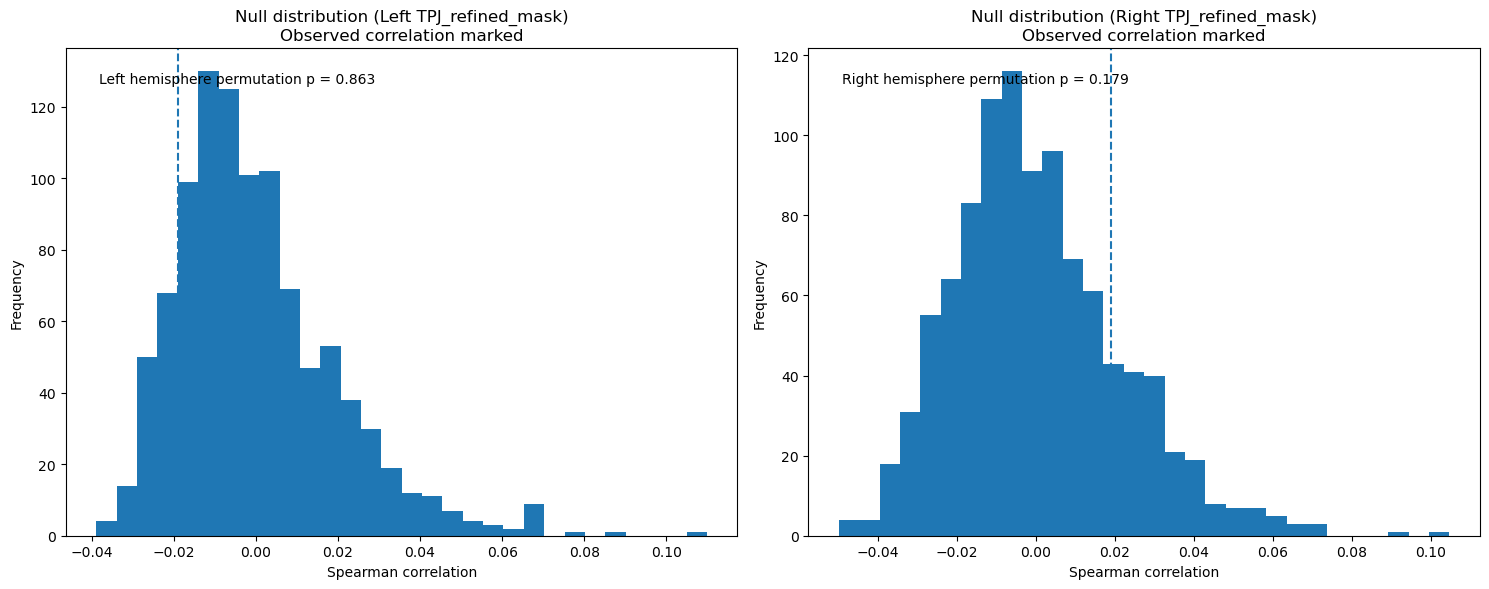

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Left ROI ---
axes[0].hist(null_left, bins=30)
axes[0].axvline(rho_left, linestyle='--')
axes[0].set_xlabel("Spearman correlation")
axes[0].set_ylabel("Frequency")
axes[0].set_title(f"Null distribution (Left {whichROI})\nObserved correlation marked")

# Add text inside the plot
axes[0].text(
    0.05, 0.95,
    f"Left hemisphere permutation p = {pval_left:.3f}",
    transform=axes[0].transAxes,
    verticalalignment="top"
)

# --- Right ROI ---
axes[1].hist(null_right, bins=30)
axes[1].axvline(rho_right, linestyle='--')
axes[1].set_xlabel("Spearman correlation")
axes[1].set_ylabel("Frequency")
axes[1].set_title(f"Null distribution (Right {whichROI})\nObserved correlation marked")

axes[1].text(
    0.05, 0.95,
    f"Right hemisphere permutation p = {pval_right:.3f}",
    transform=axes[1].transAxes,
    verticalalignment="top"
)

plt.tight_layout()

plt.savefig(str(save_dir)+'/'+f"RSArelToVirtueFam_{whichROI}_{whichStory}_{whichVersion}")
plt.show()


In [17]:
# def compute_per_participant_RDMs(patterns):
#     E, P, V = patterns.shape
#     RDMs = np.zeros((P, E, E))

#     for p in range(P):
#         for i in range(E):
#             for j in range(E):
#                 x = patterns[i, p]
#                 y = patterns[j, p]
#                 r = np.corrcoef(x, y)[0, 1]
#                 RDMs[p, i, j] = 1 - r  # dissimilarity
#     return RDMs


In [18]:
# RDMs_pp_left  = compute_per_participant_RDMs(patterns_left)
# RDMs_pp_right = compute_per_participant_RDMs(patterns_right)


In [19]:

# P, E, _ = RDMs_pp_left.shape

# cols = 5
# rows = int(np.ceil(P / cols))

# # mask to keep only upper triangle without diagonal
# mask = np.triu(np.ones((E, E)), k=1).astype(bool)

# plt.figure(figsize=(15, 3*rows))

# for p in range(P):
#     # copy
#     rdm = RDMs_pp_left[p].copy()
    
#     # apply mask → set everything else to NaN
#     masked_rdm = np.full_like(rdm, np.nan)
#     masked_rdm[mask] = rdm[mask]
    
#     plt.subplot(rows, cols, p+1)
#     plt.imshow(masked_rdm, aspect='auto')
#     plt.title(f"P{p+1}")
#     plt.axis("off")

# plt.suptitle("Per-participant RDMs (Left TPJ, upper triangle only)")
# plt.tight_layout()
# plt.show()


In [20]:
# P, E, _ = RDMs_pp_right.shape

# cols = 5
# rows = int(np.ceil(P / cols))

# # mask to keep only upper triangle without diagonal
# mask = np.triu(np.ones((E, E)), k=1).astype(bool)

# plt.figure(figsize=(15, 3*rows))

# for p in range(P):
#     # copy
#     rdm = RDMs_pp_right[p].copy()
    
#     # apply mask → set everything else to NaN
#     masked_rdm = np.full_like(rdm, np.nan)
#     masked_rdm[mask] = rdm[mask]
    
#     plt.subplot(rows, cols, p+1)
#     plt.imshow(masked_rdm, aspect='auto')
#     plt.title(f"P{p+1}")
#     plt.axis("off")

# plt.suptitle("Per-participant RDMs (right hemisphere, upper triangle only)")
# plt.tight_layout()
# plt.show()



In [21]:
# # Upper triangle mask (exclude diagonal)
# E = RDM_moralscores.shape[0]
# mask = np.triu(np.ones((E, E)), k=1).astype(bool)

# # Flatten the moral RDM upper triangle
# moral_vec = RDM_moralscores.values[mask]

# P = RDMs_pp_left.shape[0]
# corrs_left  = np.zeros(P)
# corrs_right = np.zeros(P)

# for p in range(P):
#     # flatten upper triangle of participant RDM
#     rdm_left_vec  = RDMs_pp_left[p][mask]
#     rdm_right_vec = RDMs_pp_right[p][mask]
    
#     # Spearman correlations
#     corrs_left[p], _  = spearmanr(rdm_left_vec, moral_vec)
#     corrs_right[p], _ = spearmanr(rdm_right_vec, moral_vec)


In [22]:
# plt.figure()
# plt.hist(corrs_left, bins=20)
# plt.xlabel("Spearman correlation")
# plt.ylabel("Count")
# plt.title("Per-participant RDM–moral alignment (Left hemisphere)")
# plt.show()

# plt.figure()
# plt.hist(corrs_right, bins=20)
# plt.xlabel("Spearman correlation")
# plt.ylabel("Count")
# plt.title("Per-participant RDM–moral alignment (Right hemisphere)")
# plt.show()
